In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    Flatten, BatchNormalization, Activation)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight


from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [11]:
# Change this to your dataset path
base_dir = "D:\pythonML-class\emotion_music_flask\Facial Expression"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
val_dir = os.path.join(base_dir, "validation")

img_size = 48
batch_size = 64


In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)


train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)


Found 11983 images belonging to 7 classes.
Found 6955 images belonging to 7 classes.


In [13]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))


In [14]:
model = Sequential([

    Conv2D(64, (3,3), padding='same', activation='relu',
           input_shape=(48,48,1)),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'BatchNormalization' is not defined

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-6
    )
]


In [ ]:
history = model.fit(
    train_data,
    epochs=40,
    validation_data=val_data,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.1659 - loss: 1.8467 - val_accuracy: 0.1730 - val_loss: 1.8125
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 182s 969ms/step - accuracy: 0.1737 - loss: 1.8226 - val_accuracy: 0.2017 - val_loss: 1.7881
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - accuracy: 0.2049 - loss: 1.7988 - val_accuracy: 0.2076 - val_loss: 1.7672
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 139ms/step - accuracy: 0.2266 - loss: 1.7706 - val_accuracy: 0.2495 - val_loss: 1.7315
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 135ms/step - accuracy: 0.2540 - loss: 1.7422 - val_accuracy: 0.2627 - val_loss: 1.7054
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 138ms/step - accuracy: 0.2766 - loss: 1.7156 - val_accuracy: 0.3074 - val_loss: 1.6658
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 136ms/step - accuracy: 0.2904 - loss: 1.6968 - val_accuracy: 0.3343 - val_loss: 1.6388
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 140ms/step - accuracy: 0.3007 - loss: 1.

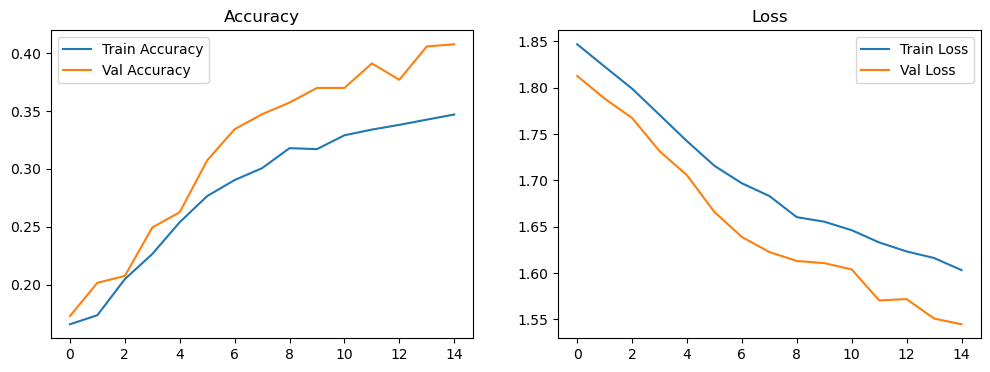

In [6]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


Found 6955 images belonging to 7 classes.
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step


In [ ]:
# spotify_df = pd.read_csv("D:\pythonML-class\emotion_music_flask\SpotifyFeatures.csv")
# spotify_df.head()


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [ ]:
# music_features = [
#     'acousticness', 'danceability', 'energy',
#     'instrumentalness', 'liveness', 'loudness',
#     'speechiness', 'tempo', 'valence'
# ]

# music_data = spotify_df[music_features]


In [ ]:
# scaler = StandardScaler()
# scaled_music = scaler.fit_transform(music_data)


In [ ]:
# emotion_music_map = {
#     'angry': {'energy': 0.9, 'valence': 0.2},
#     'happy': {'energy': 0.8, 'valence': 0.9},
#     'sad': {'energy': 0.3, 'valence': 0.2},
#     'neutral': {'energy': 0.5, 'valence': 0.5},
#     'fear': {'energy': 0.6, 'valence': 0.3},
#     'disgust': {'energy': 0.4, 'valence': 0.3},
#     'surprise': {'energy': 0.85, 'valence': 0.75}
# }


In [ ]:
# def recommend_music_smart_random(emotion, top_k=50, n=15):
#     target = np.array([
#         0, 0,
#         emotion_music_map[emotion]['energy'],
#         0, 0, 0, 0, 0,
#         emotion_music_map[emotion]['valence']
#     ]).reshape(1, -1)

#     target_scaled = scaler.transform(target)
#     similarity = cosine_similarity(target_scaled, scaled_music)

#     top_indices = similarity[0].argsort()[-top_k:]
#     candidates = spotify_df.iloc[top_indices]

#     return candidates.sample(n)[['track_name', 'artist_name', 'genre']]


In [ ]:
# emotion_labels = list(train_data.class_indices.keys())

# def predict_emotion(img_path):
#     img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
#     img = cv2.resize(img, (48,48))
#     img = img / 255.0
#     img = img.reshape(1,48,48,1)
    
#     prediction = model.predict(img)
#     return emotion_labels[np.argmax(prediction)]


In [ ]:
# recommend_music('happy')

c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,track_name,artist_name,genre
218433,Fumbling Towards The Light,John Mark McMillan,World
117480,Quickie,Miguel,Rap
16008,Quickie,Miguel,Dance
150178,Quickie,Miguel,Pop
56469,Quickie,Miguel,R&B


In [ ]:
# image_path = "D:\pythonML-class\emotion_music_flask\happy3.jpg"  # put face image here

# emotion = predict_emotion(image_path)
# print("Detected Emotion:", emotion)

# recommend_music(emotion)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Detected Emotion: angry


c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,track_name,artist_name,genre
207535,How Great a King (Live),Bethel Music,World
41968,Wasting Time,Nathaniel Rateliff & The Night Sweats,Folk
219931,하나님께서 세상을 사랑하사 (God So Loved the World),Scott Brenner & Levites,World
200749,Battleborne,Two Steps from Hell,Soundtrack
217494,Feeling Low (Live),Will Reagan,World


In [ ]:
# import cv2
# import numpy as np
# from tensorflow.keras.models import load_model

In [7]:
model.save("emotion_model.h5")


In [ ]:
# model = load_model("emotion_model.h5")


In [ ]:
# emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
# face_cascade = cv2.CascadeClassifier(
#     cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
# )


In [ ]:
# import time


In [ ]:
# cap = cv2.VideoCapture(0)

# start_time = time.time()
# detected_emotions = []

# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break

#     gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#     faces = face_cascade.detectMultiScale(
#         gray,
#         scaleFactor=1.3,
#         minNeighbors=5
#     )

#     for (x, y, w, h) in faces:
#         face = gray[y:y+h, x:x+w]
#         face = cv2.resize(face, (48,48))
#         face = face / 255.0
#         face = face.reshape(1,48,48,1)

#         prediction = model.predict(face, verbose=0)
#         emotion = emotion_labels[np.argmax(prediction)]
#         detected_emotions.append(emotion)

#         cv2.rectangle(frame, (x,y), (x+w,y+h), (0,255,0), 2)
#         cv2.putText(
#             frame,
#             emotion,
#             (x, y-10),
#             cv2.FONT_HERSHEY_SIMPLEX,
#             0.9,
#             (255,0,0),
#             2
#         )
        

#     cv2.imshow("Detecting Emotion (5 seconds)", frame)

#     # ⏱ Stop after 5 seconds
    
#     if time.time() - start_time > 8:
#         break

# cap.release()
# cv2.destroyAllWindows()



In [ ]:
# from collections import Counter

# # if len(detected_emotions) == 0:
# #     final_emotion = "neutral"
# # else:
# final_emotion = Counter(detected_emotions).most_common(1)[0][0]

# print("Final Detected Emotion:", final_emotion)



Final Detected Emotion: happy


In [ ]:
# recommend_music_random(final_emotion, n=15)


,track_name,artist_name,genre
149966,Booty Wurk (One Cheek At a Time),T-Pain,Pop
171709,Yard Sale (Underwear Song),Rodney Carrington,Comedy
138328,Ganjah en Mi habitación,Zona Ganjah,Reggae
15285,Magic (feat. Rivers Cuomo),B.o.B,Dance
135604,Flag,Xavier Rudd,Reggae
35038,春夏秋冬☆Blooming!,Masayoshi Ohishi,Anime
197212,Fate - WSM Compilation Edit,Chaka Khan,Soul
158530,La Perla,Calle 13,Reggaeton
35640,Spiral,L'Arc-en-Ciel,Anime
132104,Ravers,Steel Pulse,Reggae
